# Regression with a Single-country Example

This notebook uses the United States as a time-series-style example to illustrate descriptive statistics, variable transformation, correlation analysis, and simple OLS regression.

In [1]:
from pathlib import Path

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
    return current

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
ASSETS_DIR = PROJECT_ROOT / "assets"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT


PosixPath('/Users/hanyu/Documents/GitHub/big-data-analysis-2025')

In [2]:
MODULE_OUTPUT_DIR = OUTPUT_DIR / "04_regression_single_country"
MODULE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODULE_OUTPUT_DIR

PosixPath('/Users/hanyu/Documents/GitHub/big-data-analysis-2025/outputs/04_regression_single_country')

In [3]:
import pandas as pd

df = pd.read_csv(DATA_DIR / "wdi" / "WDI_course_subset.csv")

# Use the United States as the example country.
df_US = df[df["Country Name"] == "United States"]

WDI_US = df_US.drop(columns="Indicator Code").melt(
    id_vars=["Country Name", "Country Code", "Indicator Name"],
    var_name="Year",
).pivot_table(
    values="value",
    index=["Country Name", "Country Code", "Year"],
    columns="Indicator Name",
).reset_index().rename_axis("", axis=1)

# Convert Year from string-like values to integers.
WDI_US["Year"] = WDI_US["Year"].astype(str).astype(int)

isna_data = WDI_US.isna().sum().sort_values(ascending=True)
isna_data.to_csv(MODULE_OUTPUT_DIR / "isna_data_US.csv", index=True)

WDI_US.head()

,Country Name,Country Code,Year,Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),...,"Vulnerable employment, female (% of female employment) (modeled ILO estimate)","Vulnerable employment, male (% of male employment) (modeled ILO estimate)","Vulnerable employment, total (% of total employment) (modeled ILO estimate)","Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)","Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Women Business and the Law Index Score (scale 1-100),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
0,United States,USA,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,United States,USA,1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,United States,USA,1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,United States,USA,1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,United States,USA,1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Q1. How can we choose variables for a research question and describe them statistically?

In [4]:
# `describe()` returns count, mean, standard deviation, minimum, maximum, and quartiles.
WDI_US[
    [
        "GDP per capita (constant 2015 US$)",
        "Gross fixed capital formation (% of GDP)",
        "Trade (% of GDP)",
        "Inflation, consumer prices (annual %)",
        "Foreign direct investment, net inflows (% of GDP)",
    ]
].describe()



,GDP per capita (constant 2015 US$),Gross fixed capital formation (% of GDP),Trade (% of GDP),"Inflation, consumer prices (annual %)","Foreign direct investment, net inflows (% of GDP)"
count,65.000000,65.000000,65.000000,65.000000,55.000000
mean,40929.983640,21.717144,19.974486,3.757704,1.175130
std,13779.270033,1.249335,6.610449,2.743010,0.828228
min,18853.721751,18.313937,8.934736,-0.355546,0.066103
25%,28509.143057,21.211143,16.417895,1.898048,0.573457
50%,39447.947285,21.868721,20.044619,3.015075,1.091662
75%,53215.536232,22.474858,25.102986,4.300535,1.659606
max,66682.614704,24.426671,30.842479,13.549202,3.405781


# Q2. How can we do simple transformations before regression?

In [5]:
import numpy as np
pd.options.mode.chained_assignment = None

# Build a simple growth-regression dataset.
WDI_US["lngdpc"] = np.log(WDI_US["GDP per capita (constant 2015 US$)"])
WDI_US["capital_share"] = WDI_US["Gross fixed capital formation (% of GDP)"]
WDI_US["trade_open"] = WDI_US["Trade (% of GDP)"]
WDI_US["inflation"] = WDI_US["Inflation, consumer prices (annual %)"]
WDI_US["fdi"] = WDI_US["Foreign direct investment, net inflows (% of GDP)"]

WDI_US.to_csv(MODULE_OUTPUT_DIR / "WDI_US_transformed.csv", index=False)

WDI_US.describe()



,Year,Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)",...,"Wage and salaried workers, total (% of total employment) (modeled ILO estimate)","Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Women Business and the Law Index Score (scale 1-100),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV,lngdpc,capital_share,trade_open,inflation,fdi
count,65.00000,23.0,23.0,23.0,34.0,34.0,34.0,4.000000,4.000000,4.000000,...,33.000000,42.000000,54.000000,33.000000,12.000000,65.000000,65.000000,65.000000,65.000000,55.000000
mean,1992.00000,100.0,100.0,100.0,100.0,100.0,100.0,92.402500,92.087500,92.750000,...,92.717225,29.386525,80.937500,22.173170,7508.333333,10.559022,21.717144,19.974486,3.757704,1.175130
std,18.90767,0.0,0.0,0.0,0.0,0.0,0.0,3.061964,5.601026,0.714843,...,0.888125,10.217656,6.772662,0.235695,1468.120836,0.359362,1.249335,6.610449,2.743010,0.828228
min,1960.00000,100.0,100.0,100.0,100.0,100.0,100.0,87.960000,84.070000,91.980000,...,90.981838,13.644748,66.875000,21.544275,5600.000000,9.844466,18.313937,8.934736,-0.355546,0.066103
25%,1976.00000,100.0,100.0,100.0,100.0,100.0,100.0,91.830000,90.535000,92.265000,...,92.342862,20.993153,81.250000,22.015940,6425.000000,10.257980,21.211143,16.417895,1.898048,0.573457
50%,1992.00000,100.0,100.0,100.0,100.0,100.0,100.0,93.350000,93.745000,92.725000,...,92.780352,29.075332,83.750000,22.267748,7200.000000,10.582737,21.868721,20.044619,3.015075,1.091662
75%,2008.00000,100.0,100.0,100.0,100.0,100.0,100.0,93.922500,95.297500,93.210000,...,93.554246,39.115281,83.750000,22.368477,8575.000000,10.882106,22.474858,25.102986,4.300535,1.659606
max,2024.00000,100.0,100.0,100.0,100.0,100.0,100.0,94.950000,96.790000,93.570000,...,93.917783,47.070289,91.250000,22.415700,10000.000000,11.107700,24.426671,30.842479,13.549202,3.405781


## 2.1 Select complete years and export a transposed descriptive statistics table

In [6]:
# The variables below are reasonably complete after 1990, so we trim the sample period.
ols_selected = WDI_US[(WDI_US["Year"] < 2021) & (WDI_US["Year"] > 1990)]

summary_table = ols_selected[
    ["lngdpc", "capital_share", "trade_open", "inflation", "fdi"]
].describe().T

summary_table.to_csv(MODULE_OUTPUT_DIR / "summary_table.csv", index=True)
summary_table



,count,mean,std,min,25%,50%,75%,max
,,,,,,,,
lngdpc,30.0,10.823081,0.132936,10.561987,10.736407,10.863893,10.907501,11.019415
capital_share,30.0,21.061210,1.301006,18.313937,20.188711,21.265735,22.001452,23.146270
trade_open,30.0,25.195743,3.313900,19.786448,22.721777,24.931257,27.627500,30.842479
inflation,30.0,2.309360,1.009040,-0.355546,1.626678,2.390137,2.946544,4.234964
fdi,30.0,1.601958,0.773325,0.464854,1.026502,1.503587,2.105696,3.405781


## 2.2 How can we compute a correlation matrix with significance stars?

In [7]:
cor_data = ols_selected[
    ["lngdpc", "capital_share", "trade_open", "inflation", "fdi"]
]

from scipy.stats import pearsonr

rho = cor_data.corr()
pval = cor_data.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: "".join(["*" for t in [0.05, 0.01, 0.001] if x <= t]))
correlation = rho.round(4).astype(str) + p

correlation.to_csv(MODULE_OUTPUT_DIR / "correlation.csv", index=True)
correlation



/var/folders/6v/nc250lnx4qs4c1hjd2jt44_00000gn/T/ipykernel_64097/2265633460.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  p = pval.applymap(lambda x: "".join(["*" for t in [0.05, 0.01, 0.001] if x <= t]))


,lngdpc,capital_share,trade_open,inflation,fdi
,,,,,
lngdpc,1.0***,0.0507,0.7631***,-0.436*,0.3549
capital_share,0.0507,1.0***,-0.2105,0.3067,0.379*
trade_open,0.7631***,-0.2105,1.0***,-0.1849,0.4442*
inflation,-0.436*,0.3067,-0.1849,1.0***,-0.1042
fdi,0.3549,0.379*,0.4442*,-0.1042,1.0***


### If you want to export a table to Word format, see:
https://rowannicholls.github.io/python/data/export_to_word.html

## 2.3 The same correlation matrix can also be visualized as a heat map.

In [8]:
%pip install -q seaborn

Note: you may need to restart the kernel to use updated packages.


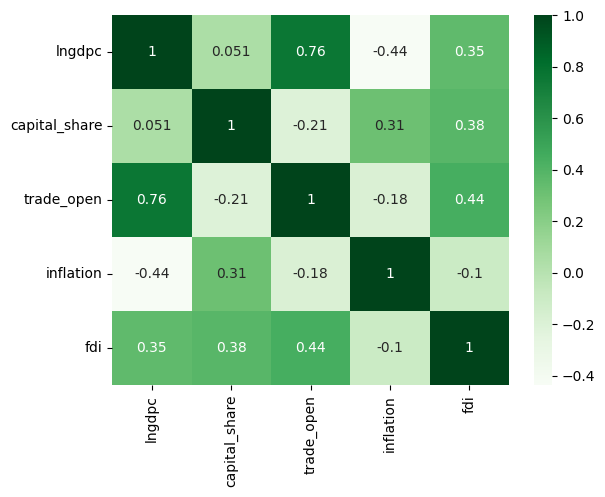

In [9]:
import seaborn as sb
import matplotlib.pyplot as plt

sb.heatmap(rho, cmap="Greens", annot=True)
plt.savefig(MODULE_OUTPUT_DIR / "heatmap.png", bbox_inches="tight")

# Q3. How can we run a simple OLS regression?

In [10]:
%pip install -q statsmodels openpyxl

Note: you may need to restart the kernel to use updated packages.


## 3.1 Run a basic single-equation OLS model

In [11]:
import statsmodels.api as sm

# Define predictor and response variables.
y = ols_selected["lngdpc"]
x = ols_selected["capital_share"]

# Add a constant and fit the model.
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()

print(model.summary())



                            OLS Regression Results                            
Dep. Variable:                 lngdpc   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.033
Method:                 Least Squares   F-statistic:                   0.07203
Date:                Fri, 20 Mar 2026   Prob (F-statistic):              0.790
Time:                        13:22:45   Log-Likelihood:                 18.516
No. Observations:                  30   AIC:                            -33.03
Df Residuals:                      28   BIC:                            -30.23
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            10.7141      0.407     26.330

## 3.2 Export a regression table with significance stars

In [12]:
from statsmodels.iolib.summary2 import summary_col

# Define the dependent variable.
y = ols_selected[["lngdpc"]]

# Define the independent variables.
X1 = ols_selected[["capital_share"]]
X2 = ols_selected[["capital_share", "trade_open"]]
X3 = ols_selected[["capital_share", "trade_open", "inflation"]]
X4 = ols_selected[["capital_share", "trade_open", "inflation", "fdi"]]

# Add constant terms.
X1 = sm.add_constant(X1)
X2 = sm.add_constant(X2)
X3 = sm.add_constant(X3)
X4 = sm.add_constant(X4)

# Fit OLS models.
model1 = sm.OLS(y, X1).fit()
model2 = sm.OLS(y, X2).fit()
model3 = sm.OLS(y, X3).fit()
model4 = sm.OLS(y, X4).fit()

# Create a summary table with significance stars.
reg = summary_col(
    [model1, model2, model3, model4],
    stars=True,
    model_names=["Model 1", "Model 2", "Model 3", "Model 4"],
    float_format="%0.2f",
    info_dict={"N": lambda result: result.nobs},
)

reg_df = reg.tables[0].reset_index(drop=False)
reg_df.to_excel(MODULE_OUTPUT_DIR / "regression_results.xlsx", index=False)

reg_df



,index,Model 1,Model 2,Model 3,Model 4
0,const,10.71***,9.53***,9.46***,9.08***
1,,(0.41),(0.31),(0.25),(0.28)
2,capital_share,0.01,0.02*,0.03***,0.05***
3,,(0.02),(0.01),(0.01),(0.01)
4,trade_open,,0.03***,0.03***,0.04***
5,,,(0.00),(0.00),(0.00)
6,inflation,,,-0.05***,-0.06***
7,,,,(0.01),(0.01)
8,fdi,,,,-0.05**
9,,,,,(0.02)


## 3.3 How can we draw a fitted line?

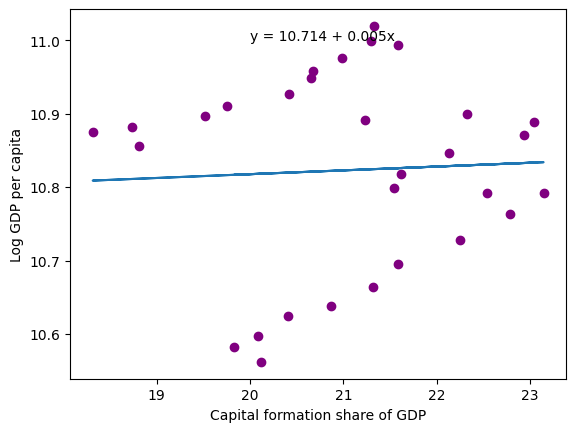

In [13]:
# Find the best-fitting line.
a, b = np.polyfit(ols_selected["capital_share"], ols_selected["lngdpc"], 1)

# Add the scatter points.
plt.scatter(ols_selected["capital_share"], ols_selected["lngdpc"], color="purple")

# Add the fitted line.
plt.plot(ols_selected["capital_share"], a * ols_selected["capital_share"] + b)

# Add the fitted equation.
plt.text(20, 11, "y = " + "{:.3f}".format(b) + " + {:.3f}".format(a) + "x")

# Add axis labels.
plt.xlabel("Capital formation share of GDP")
plt.ylabel("Log GDP per capita")
plt.savefig(MODULE_OUTPUT_DIR / "fitted_line.png", bbox_inches="tight")

